# Introducción
En esta unidad, exploraremos el Análisis de Redes Sociales (SNA) utilizando herramientas de Python. El SNA se aplica no solo a redes sociales populares como Twitter o Facebook, sino también a relaciones internas en empresas, comunicación entre repositorios de software, propagación de información en comunidades de desarrolladores, y más.


## 1.2 Grafos y redes, ¿qué son?
Un grafo se define como un par (V, E), donde V es el conjunto de nodos y E el conjunto de aristas. En redes sociales, los nodos representan actores sociales y las aristas describen relaciones o interacciones.

## 1.3 Tipos de redes
- **Redes no dirigidas**: Relaciones bidireccionales (amistad en Facebook).
- **Redes dirigidas**: Relaciones con dirección específica (seguidores en Twitter).
- **Redes ponderadas**: Relaciones con intensidad o peso (frecuencia de mensajes).
- **Redes bipartitas**: Nodos divididos en dos conjuntos disjuntos (usuarios y productos).

## 1.4 Propiedades fundamentales
- **Grado de un nodo**: Número de conexiones de un nodo.
- **Densidad**: Proporción de conexiones posibles presentes en el grafo.
- **Diámetro**: Máxima distancia entre cualquier par de nodos.
- **Conectividad**: Determina si hay un camino que conecte todos los nodos de la red.

In [ ]:
!pip install networks

Nodos del grafo:
['A', 'B', 'C', 'D', 'E']

Aristas del grafo con pesos:
[('A', 'B', {'weight': 4}), ('A', 'C', {'weight': 2}), ('B', 'C', {'weight': 1}), ('B', 'D', {'weight': 5}), ('C', 'D', {'weight': 8}), ('C', 'E', {'weight': 10}), ('D', 'E', {'weight': 2})]

Camino más corto de A a E:
['A', 'C', 'B', 'D', 'E']

Distancia total:
10


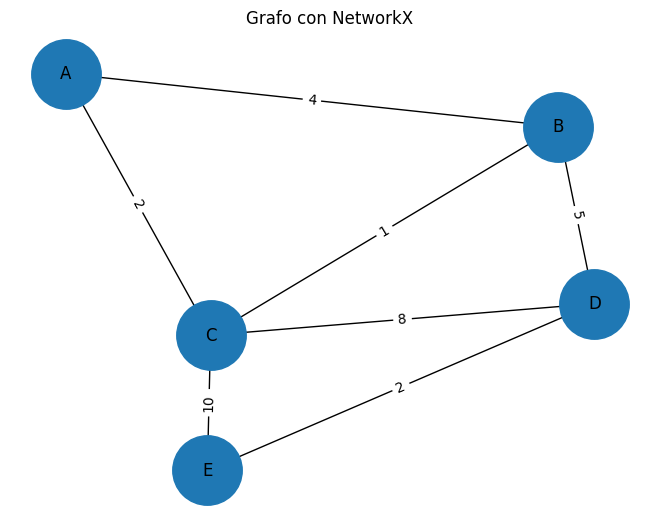

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Crear un grafo no dirigido
G = nx.Graph()

# 2. Añadir nodos
G.add_nodes_from(["A", "B", "C", "D", "E"])

# 3. Añadir aristas con peso
G.add_edge("A", "B", weight=4)
G.add_edge("A", "C", weight=2)
G.add_edge("B", "C", weight=1)
G.add_edge("B", "D", weight=5)
G.add_edge("C", "D", weight=8)
G.add_edge("C", "E", weight=10)
G.add_edge("D", "E", weight=2)

# 4. Mostrar nodos y aristas
print("Nodos del grafo:")
print(G.nodes())

print("\nAristas del grafo con pesos:")
print(G.edges(data=True))

# 5. Calcular el camino más corto entre A y E usando el peso
camino = nx.shortest_path(G, source="A", target="E", weight="weight")
distancia = nx.shortest_path_length(G, source="A", target="E", weight="weight")

print("\nCamino más corto de A a E:")
print(camino)

print("\nDistancia total:")
print(distancia)

# 6. Dibujar el grafo
pos = nx.spring_layout(G, seed=42)  # posición de los nodos
labels = nx.get_edge_attributes(G, "weight")

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=12
)

nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Grafo con NetworkX")
plt.show()

### Crear un Grafo a partir de un dataframe

Aristas simples:
   id_email               fecha             source               target  \
0         1 2026-03-01 09:00:00    ana@empresa.com     luis@empresa.com   
0         1 2026-03-01 09:00:00    ana@empresa.com  soporte@empresa.com   
1         2 2026-03-01 10:15:00   luis@empresa.com      ana@empresa.com   
2         3 2026-03-01 11:00:00    ana@empresa.com    marta@empresa.com   
2         3 2026-03-01 11:00:00    ana@empresa.com     luis@empresa.com   
3         4 2026-03-02 08:30:00  marta@empresa.com      ana@empresa.com   
3         4 2026-03-02 08:30:00  marta@empresa.com     luis@empresa.com   
4         5 2026-03-02 12:00:00    ana@empresa.com  soporte@empresa.com   

                asunto  
0      Informe mensual  
0      Informe mensual  
1   Revisión documento  
2  Reunión de proyecto  
2  Reunión de proyecto  
3   Incidencia técnica  
3   Incidencia técnica  
4   Seguimiento ticket  

Aristas agregadas:
              source               target  num_emails        u

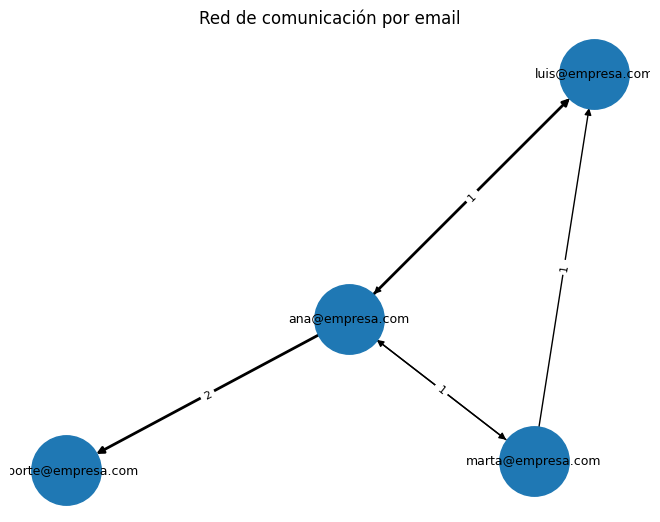

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# DataFrame original: cada fila es un email
emails = pd.DataFrame({
    "id_email": [1, 2, 3, 4, 5],
    "fecha": pd.to_datetime([
        "2026-03-01 09:00",
        "2026-03-01 10:15",
        "2026-03-01 11:00",
        "2026-03-02 08:30",
        "2026-03-02 12:00"
    ]),
    "remitente": [
        "ana@empresa.com",
        "luis@empresa.com",
        "ana@empresa.com",
        "marta@empresa.com",
        "ana@empresa.com"
    ],
    "destinatarios": [
        ["luis@empresa.com", "soporte@empresa.com"],
        ["ana@empresa.com"],
        ["marta@empresa.com", "luis@empresa.com"],
        ["ana@empresa.com", "luis@empresa.com"],
        ["soporte@empresa.com"]
    ],
    "asunto": [
        "Informe mensual",
        "Revisión documento",
        "Reunión de proyecto",
        "Incidencia técnica",
        "Seguimiento ticket"
    ]
})

# 1) Pasar de emails a pares remitente -> destinatario
edges = emails.explode("destinatarios").rename(
    columns={
        "remitente": "source",
        "destinatarios": "target"
    }
)

# Limpiar nulos o auto-envíos si no los quieres
edges = edges.dropna(subset=["source", "target"])
edges = edges[edges["source"] != edges["target"]]

print("Aristas simples:")
print(edges[["id_email", "fecha", "source", "target", "asunto"]])

# 2) Agregar para que cada arista tenga información resumida
edges_agg = (
    edges.sort_values("fecha")
         .groupby(["source", "target"], as_index=False)
         .agg(
             num_emails=("id_email", "count"),
             ultima_fecha=("fecha", "max"),
             ultimo_asunto=("asunto", "last")
         )
)

print("\nAristas agregadas:")
print(edges_agg)

# 3) Crear grafo dirigido
G = nx.from_pandas_edgelist(
    edges_agg,
    source="source",
    target="target",
    edge_attr=["num_emails", "ultima_fecha", "ultimo_asunto"],
    create_using=nx.DiGraph()
)

# 4) Métricas básicas
print("\nNodos:")
print(list(G.nodes()))

print("\nAristas con atributos:")
for u, v, data in G.edges(data=True):
    print(f"{u} -> {v}: {data}")

print("\nGrado de salida (emails enviados):")
for nodo, grado in G.out_degree():
    print(nodo, grado)

print("\nGrado de entrada (emails recibidos):")
for nodo, grado in G.in_degree():
    print(nodo, grado)

# 5) Dibujar
pos = nx.spring_layout(G, seed=42)

# Grosor de arista según cantidad de emails
weights = [G[u][v]["num_emails"] for u, v in G.edges()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9,
    width=weights
)

# Etiquetas de arista = número de emails
edge_labels = {(u, v): G[u][v]["num_emails"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Red de comunicación por email")
plt.axis("off")
plt.show()

## Creación y manipulación de grafos
NetworkX permite crear grafos dirigidos, no dirigidos y multigrafos. Las clases principales son:
- **Graph**: Redes no dirigidas.
- **DiGraph**: Redes dirigidas.
- **MultiGraph**: Redes no dirigidas con múltiples aristas entre nodos.
- **MultiDiGraph**: Variante dirigida del anterior.


### Ejercicios

Dispones de un conjunto de datos en forma de `DataFrame` que representa relaciones de seguimiento en Instagram. Cada fila indica que un usuario sigue a otro usuario. A partir de esa información, construye desde cero una red de seguidores utilizando **Python**, **pandas** y **NetworkX**.

Debes modelar la red de forma adecuada, justificar brevemente el tipo de grafo elegido y, una vez construida, realizar un análisis que permita responder a las siguientes cuestiones:

1. ¿Qué cuenta tiene más seguidores?
2. ¿Qué cuenta sigue a más personas?
3. ¿Qué cuenta parece más influyente según una métrica de centralidad adecuada?
4. ¿Qué usuario actúa más como puente entre distintos grupos de cuentas?
5. ¿Coincide la cuenta con más seguidores con la más influyente? Explica por qué sí o por qué no.
6. ¿Qué ocurre en la estructura de la red si eliminas al usuario que actúa como mayor puente?
7. ¿Se puede identificar alguna cuenta que parezca popular por número de seguidores pero que no tenga tanta relevancia estructural dentro de la red?

Además, representa visualmente la red y destaca de alguna forma los nodos más relevantes según las métricas que hayas calculado.



In [4]:
df = pd.DataFrame({
    "follower": [
        # --- Comunidad fitness ---
        "laura_fit", "carla_fit", "diego_fit", "alex_runner", "miguel_gym",
        "sofia_active", "nutri_ana", "carla_fit", "diego_fit", "alex_runner",
        "miguel_gym", "sofia_active", "nutri_ana",

        # --- Comunidad moda ---
        "clara_style", "eva_style", "chic_maria", "trend_ana", "moda_daily",
        "eva_style", "chic_maria", "trend_ana", "moda_daily",

        # --- Comunidad viajes ---
        "paula_trip", "mario_trip", "lucia_nomad", "travel_now", "foto_mundo",
        "mario_trip", "lucia_nomad", "travel_now", "foto_mundo",

        # --- Puentes entre comunidades ---
        "sara_media", "sara_media", "sara_media", "sara_media", "sara_media",
        "sara_media", "sara_media",

        "laura_fit", "clara_style", "paula_trip", "insta_news",
        "carla_fit", "eva_style", "travel_now",

        # --- Nodo muy influyente / central ---
        "laura_fit", "clara_style", "paula_trip", "sara_media", "alex_runner",
        "eva_style", "lucia_nomad", "miguel_gym",

        # --- Falso influencer con seguidores débiles ---
        "bot_01", "bot_02", "bot_03", "bot_04", "bot_05", "bot_06", "bot_07",

        # --- Algunas relaciones cruzadas extra para complicar el análisis ---
        "alex_runner", "trend_ana", "foto_mundo", "chic_maria", "lucia_nomad",
        "nutri_ana", "moda_daily", "travel_now", "diego_fit", "mario_trip"
    ],
    "followed": [
        # --- Comunidad fitness ---
        "carla_fit", "diego_fit", "alex_runner", "miguel_gym", "sofia_active",
        "nutri_ana", "laura_fit", "laura_fit", "laura_fit", "laura_fit",
        "diego_fit", "carla_fit", "alex_runner",

        # --- Comunidad moda ---
        "eva_style", "chic_maria", "trend_ana", "moda_daily", "clara_style",
        "clara_style", "clara_style", "eva_style", "trend_ana",

        # --- Comunidad viajes ---
        "mario_trip", "lucia_nomad", "travel_now", "foto_mundo", "paula_trip",
        "paula_trip", "paula_trip", "lucia_nomad", "travel_now",

        # --- Puentes entre comunidades ---
        "laura_fit", "clara_style", "paula_trip", "insta_news", "viral_top",
        "travel_now", "moda_daily",

        "sara_media", "sara_media", "sara_media", "sara_media",
        "insta_news", "insta_news", "insta_news",

        # --- Nodo muy influyente / central ---
        "insta_news", "insta_news", "insta_news", "insta_news", "insta_news",
        "insta_news", "insta_news", "insta_news",

        # --- Falso influencer con seguidores débiles ---
        "viral_top", "viral_top", "viral_top", "viral_top", "viral_top", "viral_top", "viral_top",

        # --- Algunas relaciones cruzadas extra para complicar el análisis ---
        "trend_ana", "foto_mundo", "alex_runner", "travel_now", "chic_maria",
        "moda_daily", "paula_trip", "carla_fit", "insta_news", "sara_media"
    ]
})

print(df)

       follower      followed
0     laura_fit     carla_fit
1     carla_fit     diego_fit
2     diego_fit   alex_runner
3   alex_runner    miguel_gym
4    miguel_gym  sofia_active
..          ...           ...
65    nutri_ana    moda_daily
66   moda_daily    paula_trip
67   travel_now     carla_fit
68    diego_fit    insta_news
69   mario_trip    sara_media

[70 rows x 2 columns]


# Métricas de grado
Las métricas de grado son fundamentales en teoría de grafos:
- **Grado de salida (out-degree)**: Número de aristas que salen de un nodo (correos enviados).
- **Grado de entrada (in-degree)**: Número de aristas que llegan a un nodo (correos recibidos).

Además, podemos hablar de degree centrality en su forma normalizada, que en un grafo de 𝑛 nodos toma valores entre 0 y 1, siendo la fracción de nodos a los que un nodo está conectado (para out-degree en un grafo dirigido) o de los que recibe conexiones (para in-degree).
En el caso Enron podemos interpretarlas como:
-	Mayor in-degree: empleados que más correos han recibido. Podrían ser asistencias ejecutivas, directivos que reciben reportes, cuentas de distribución, etc.
-	Mayor out-degree: empleados que más correos envían, a menudo figuras que gestionan la información y la reparten (jefes de proyecto, secretarías, responsables de comunicación interna).

## Centralidad de intermediación (Betweenness Centrality)
La centralidad de intermediación mide hasta qué punto un nodo se sitúa en los caminos más cortos entre otros pares de nodos, actuando como puente o broker de información. **Es crucial para identificar cuellos de botella o puntos de control en la red.**

NetworkX proporciona una función betweenness_centrality que, por defecto, asume un grafo no ponderado. En redes de tamaño medio, el cálculo de betweenness puede ser pesado computacionalmente. Existen versiones aproximadas que permiten acelerar el proceso, como nx.betweenness_centrality_subset o el uso de muestras.


La centralidad de intermediación de un nodo \( v \) se da por la expresión:

$$
g(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}
$$

donde $ \sigma_{st}$ es el número total de caminos más cortos desde el nodo $ s $ al nodo $ t $ y $ \sigma_{st}(v) $ es el número de esos caminos que pasan por $ v $ (no donde $ v $ es un punto final).


In [5]:
b_c = nx.betweenness_centrality(G, normalized=True)
b_c

{'ana@empresa.com': 0.5,
 'luis@empresa.com': 0.0,
 'marta@empresa.com': 0.0,
 'soporte@empresa.com': 0.0}

##  Centralidad de cercanía (Closeness Centrality)
La centralidad de cercanía indica qué tan cerca está un nodo, en promedio, del resto de los nodos, considerando las rutas más cortas. Refleja el potencial de difusión de información. Funciona solo sobre grafos no dirigidos.

In [6]:
closeness_dict = nx.closeness_centrality(G.to_undirected())
top10_closeness = sorted(closeness_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 (closeness centrality, sin dirección):", top10_closeness)


Top 10 (closeness centrality, sin dirección): [('ana@empresa.com', 1.0), ('luis@empresa.com', 0.75), ('marta@empresa.com', 0.75), ('soporte@empresa.com', 0.6)]


##  Centralidad de autovector (Eigenvector Centrality) y PageRank
Estas métricas ponderan la importancia de quién te conecta. Un nodo es importante si está conectado con nodos importantes. PageRank, popularizado por Google, mide la importancia de páginas web y se adapta bien a grafos dirigidos.


In [7]:
# Eigenvector Centrality
ev_centrality = nx.eigenvector_centrality(G.to_undirected(), max_iter=1000)
top3_ev = sorted(ev_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 (Eigenvector Centrality):", top3_ev)

# PageRank
pagerank_dict = nx.pagerank(G, alpha=0.85)
top3_pr = sorted(pagerank_dict.items(), key=lambda x: x[1], reverse=True)[:3]
print("Top 3 (PageRank):", top3_pr)

Top 3 (Eigenvector Centrality): [('ana@empresa.com', 0.6116286437343044), ('luis@empresa.com', 0.5227204550943347), ('marta@empresa.com', 0.5227204550943347)]
Top 3 (PageRank): [('ana@empresa.com', 0.3749109368032264), ('luis@empresa.com', 0.26007356911464063), ('marta@empresa.com', 0.18250774704106643)]


### Ejercicio : análisis de una red de transporte entre estaciones

## Reto

Una ciudad quiere analizar su red de transporte metropolitano para detectar estaciones clave. Se ha modelado la red como un grafo, donde cada nodo representa una estación y cada arista indica una conexión directa entre dos estaciones.

La red viene dada por las siguientes conexiones:

```python
edges = [
    ("Central", "Norte"),
    ("Central", "Sur"),
    ("Central", "Universidad"),
    ("Norte", "Hospital"),
    ("Sur", "Aeropuerto"),
    ("Universidad", "Tecnologico"),
    ("Tecnologico", "Estadio"),
    ("Hospital", "Estadio"),
    ("Aeropuerto", "Puerto"),
    ("Puerto", "Estadio"),
    ("Estadio", "Museo"),
    ("Museo", "CentroHistorico"),
    ("CentroHistorico", "Central")
]
```
## Objetivo

Analizar una red de transporte para identificar qué estaciones son más importantes según distintos criterios.  
En cada apartado, el estudiante debe decidir qué métrica de centralidad utilizar y justificar su elección.

## Cuestiones

1. ¿Qué estación parece más importante por estar conectada con otras estaciones relevantes?

2. ¿En qué estación convendría colocar un punto de información para estar lo más cerca posible del resto?

3. ¿Qué estación actúa más como puente entre distintas zonas de la red?

4. Si una estación fallara y afectara mucho al funcionamiento general de la red, ¿cuál sería la más crítica?


5. Si se añade una conexión directa entre `Aeropuerto` y `Museo`, indique qué tipo de centralidad cree que cambiaría más y por qué.

#  ANÁLISIS DE COMUNIDADES CON NETWORKX O COMMUNITY
## Introducción
El análisis de comunidades en redes sociales permite identificar agrupamientos o subredes dentro de la red global.


## Métodos para la detección de comunidades
Existen varios algoritmos para la detección de comunidades:
- **Girvan–Newman**: Elimina aristas con alta intermediación iterativamente para dividir la red en grupos.
- **Louvain**: Maximiza la modularidad agrupando nodos jerárquicamente.
- **Leiden**: Mejora Louvain para evitar artefactos y refinar la partición.
- **Propagación de rótulos**: Los nodos adoptan la etiqueta de la mayoría de sus vecinos hasta converger.




### Louvain
El algoritmo Louvain trabaja con grafos no dirigidos. Ejemplo de implementación:

In [22]:
import networkx as nx
from networkx.algorithms import community

# Convertimos a grafo no dirigido
G_undirected = G.to_undirected()
# Aplicamos Louvain, asumiendo un grafo sin pesos
communities_louvain = community.louvain_communities(G_undirected, weight=None, resolution=1.0, seed=None)
print(f"Número de comunidades detectadas: {len(communities_louvain)}")
print(f"Comunidades (primeras 3): {list(communities_louvain)[:3]}")

# Para medir la calidad de la partición:
mod = community.modularity(G_undirected, communities_louvain, weight=None)
print(f"Modularidad de la partición (Louvain): {mod:.4f}")



Número de comunidades detectadas: 2
Comunidades (primeras 3): [{'luis@empresa.com', 'marta@empresa.com'}, {'soporte@empresa.com', 'ana@empresa.com'}]
Modularidad de la partición (Louvain): 0.0000


### Girvan–Newman
El algoritmo Girvan–Newman elimina aristas con alta intermediación para dividir la red en subcomponentes. Ejemplo de implementación:

In [23]:
# Lento
gn_generator = community.girvan_newman(G_undirected)
first_partition = next(gn_generator)
print("Partición con 2 comunidades:", [list(c) for c in first_partition])
second_partition = next(gn_generator)
print("Partición con 3 comunidades:", [list(c) for c in second_partition])

# Para optimizar el cálculo, se puede trabajar con subsets:
nodes_subset = list(G_undirected.nodes())[:500]
G_subset = G_undirected.subgraph(nodes_subset).copy()
gn_generator = community.girvan_newman(G_subset)
first_partition = next(gn_generator)
print("Partition with 2 communities:", [list(c) for c in first_partition])
second_partition = next(gn_generator)
print("Partition with 3 communities:", [list(c) for c in second_partition])

# Evaluar la partición con community.modularity:
best_modularity = -1
best_partition = None
for idx, partition_gn in enumerate(community.girvan_newman(G_subset)):
    partition_list = list(partition_gn)
    mod_gn = community.modularity(G_subset, partition_list)
    print(f"Iteración {idx+1} -> {len(partition_list)} comunidades, modularidad = {mod_gn:.4f}")
    if mod_gn > best_modularity:
        best_modularity = mod_gn
        best_partition = partition_list
    else:
        break
print(f"Mejor modularidad con {len(best_partition)} comunidades: {best_modularity:.4f}")


Partición con 2 comunidades: [['luis@empresa.com', 'marta@empresa.com', 'ana@empresa.com'], ['soporte@empresa.com']]
Partición con 3 comunidades: [['ana@empresa.com'], ['luis@empresa.com', 'marta@empresa.com'], ['soporte@empresa.com']]
Partition with 2 communities: [['luis@empresa.com', 'marta@empresa.com', 'ana@empresa.com'], ['soporte@empresa.com']]
Partition with 3 communities: [['ana@empresa.com'], ['luis@empresa.com', 'marta@empresa.com'], ['soporte@empresa.com']]
Iteración 1 -> 2 comunidades, modularidad = -0.0312
Iteración 2 -> 3 comunidades, modularidad = -0.1562
Mejor modularidad con 2 comunidades: -0.0312


### Ejercicio :En una red de correos electrónicos:

- `ana@empresa.com` se escribe con `bea@empresa.com` y `carlos@empresa.com`
- `bea@empresa.com` se escribe con `ana@empresa.com` y `carlos@empresa.com`
- `carlos@empresa.com` se escribe con `ana@empresa.com`, `bea@empresa.com` y `david@empresa.com`
- `david@empresa.com` se escribe con `carlos@empresa.com`, `elena@empresa.com` y `felipe@empresa.com`
- `elena@empresa.com` se escribe con `david@empresa.com` y `felipe@empresa.com`
- `felipe@empresa.com` se escribe con `david@empresa.com` y `elena@empresa.com`

### Se pide
1. Identifica los grupos de correos que parecen formar comunidades.
2. Señala el nodo o enlace que hace de puente entre ambos grupos.
3. Razona si **Louvain** y **Girvan–Newman** deberían encontrar la misma división.
4. Supón ahora que aparece una nueva conexión directa entre `bea@empresa.com` y `elena@empresa.com`. Explica si esa nueva arista haría más difícil detectar las comunidades y razona cuál de los dos algoritmos crees que sería más sensible a este cambio.